## Import Libraries

In [1]:
import pandas as pd
import plotly.express as px

C:\Users\sayam\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Load Dataset and Inspect

In [3]:
df = pd.read_csv(r"C:\Users\sayam\Desktop\Atmosync\Data\sensor_data.csv")
df.head()

,container_id,shipment_id,fruit_type,origin,destination,temperature,humidity,vibration,battery_level,door_status,container_status,latitude,longitude,timestamp
0,C026,S00303,Grapes,Ahmedabad,Kolkata,3.75,89.77,3.60,77,Closed,In Transit,23.043353,72.620371,2026-07-09 22:23:55
1,C007,S00370,Grapes,Delhi,Pune,5.20,73.92,1.76,80,Closed,In Transit,28.571831,77.238304,2026-07-04 16:38:55
2,C059,S00774,Mango,Mumbai,Hyderabad,2.33,85.02,1.32,100,Closed,In Transit,19.114280,72.860359,2026-07-09 12:59:55
3,C020,S00219,Grapes,Hyderabad,Kolkata,4.72,70.44,2.52,90,Open,Delivered,17.339452,78.500144,2026-07-05 21:42:55
4,C090,S00407,Apple,Pune,Delhi,5.80,83.94,1.57,100,Closed,Unloading,18.526444,73.873920,2026-07-09 21:05:55


In [4]:
print(df.shape)

(10000, 14)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   container_id      10000 non-null  str    
 1   shipment_id       10000 non-null  str    
 2   fruit_type        10000 non-null  str    
 3   origin            10000 non-null  str    
 4   destination       10000 non-null  str    
 5   temperature       10000 non-null  float64
 6   humidity          10000 non-null  float64
 7   vibration         10000 non-null  float64
 8   battery_level     10000 non-null  int64  
 9   door_status       10000 non-null  str    
 10  container_status  10000 non-null  str    
 11  latitude          10000 non-null  float64
 12  longitude         10000 non-null  float64
 13  timestamp         10000 non-null  str    
dtypes: float64(5), int64(1), str(8)
memory usage: 1.7 MB


In [6]:
df.isnull().sum()

container_id        0
shipment_id         0
fruit_type          0
origin              0
destination         0
temperature         0
humidity            0
vibration           0
battery_level       0
door_status         0
container_status    0
latitude            0
longitude           0
timestamp           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

## Temperature Distribution

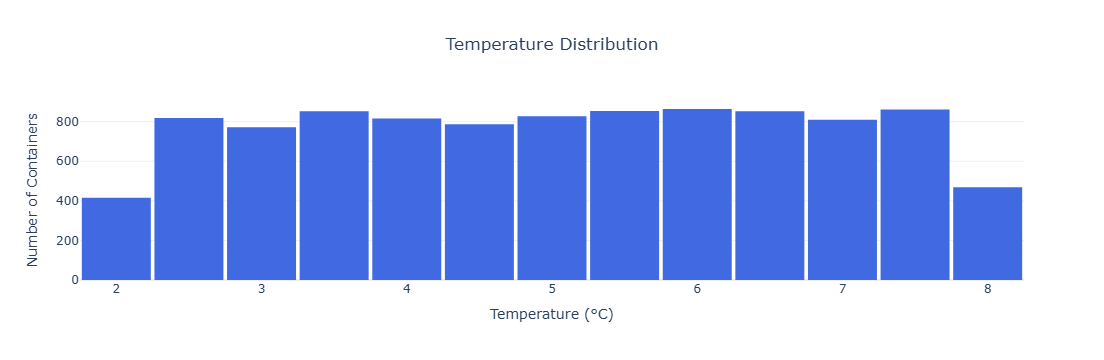

In [17]:
fig = px.histogram(df,x="temperature",nbins=30,title="Temperature Distribution",color_discrete_sequence=["royalblue"])
fig.update_layout(template="plotly_white",title_x=0.5,bargap=0.05,xaxis_title="Temperature (°C)",yaxis_title="Number of Containers")
fig.show()

## Humidity Distribution

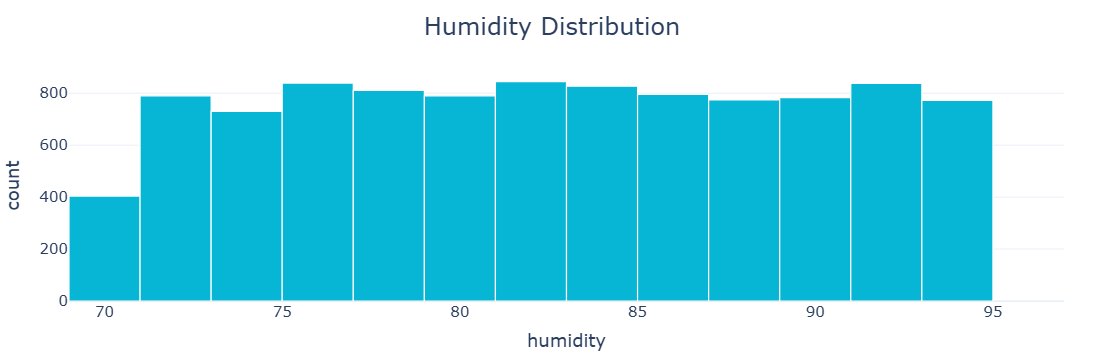

In [22]:
fig = px.histogram(df,x="humidity",nbins=25,title="Humidity Distribution",color_discrete_sequence=["#06B6D4"])
fig.update_layout(**layout)
fig.update_traces(marker_line_color="white",marker_line_width=1.2)
fig.show()

## Fruit Distribution

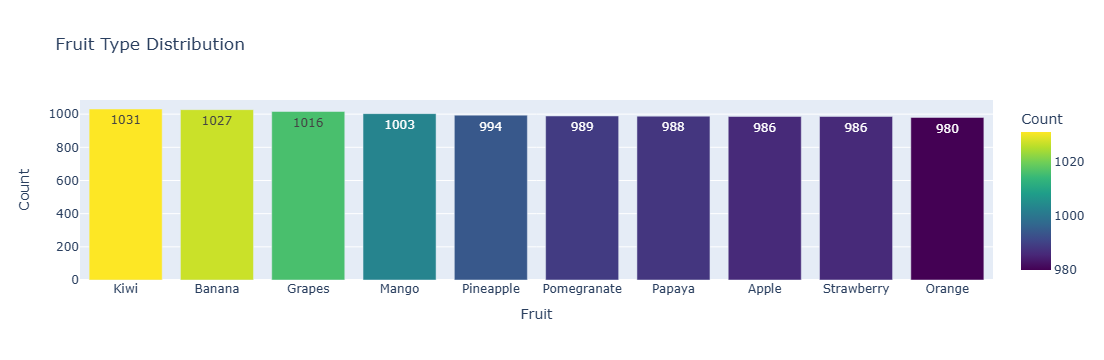

In [19]:
fruit = df["fruit_type"].value_counts().reset_index()
fruit.columns = ["Fruit","Count"]
fig = px.bar(fruit,x="Fruit",y="Count",text="Count",title="Fruit Type Distribution",color="Count",color_continuous_scale="Viridis")
fig.show()

## Container Status

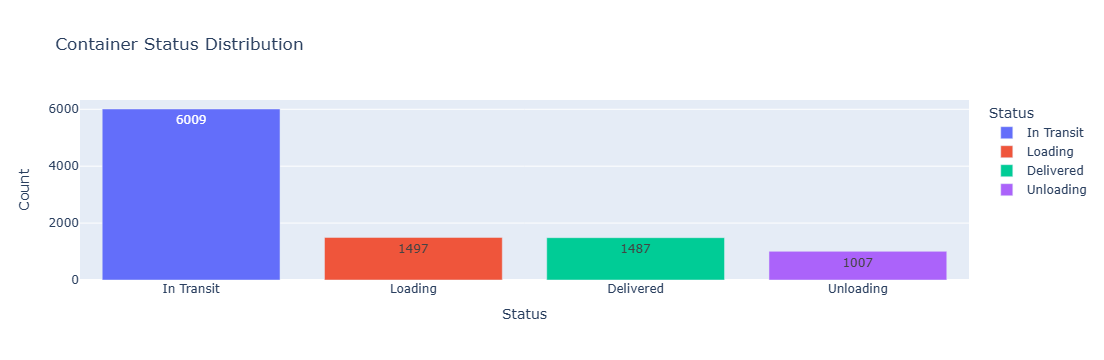

In [18]:
status = df["container_status"].value_counts().reset_index()
status.columns=["Status","Count"]
fig = px.bar(status,x="Status",y="Count",text="Count",color="Status",title="Container Status Distribution")
fig.show()

## Door Status

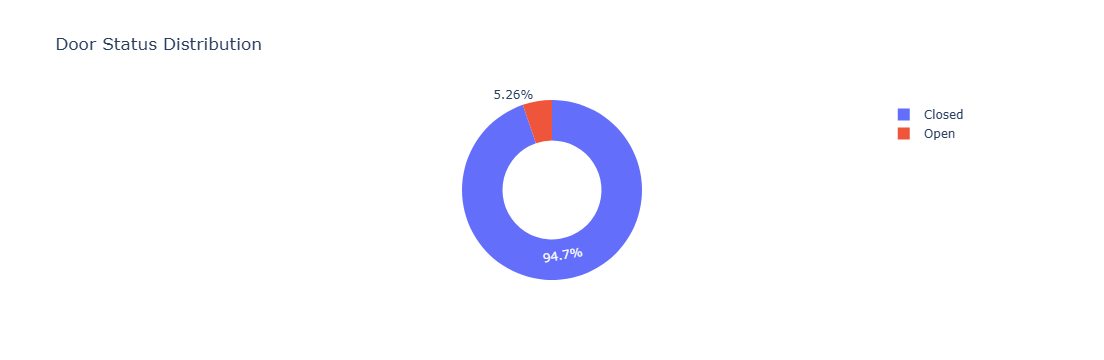

In [25]:
door=df["door_status"].value_counts().reset_index()
door.columns=["Door Status","Count"]
fig=px.pie(door,names="Door Status",values="Count",hole=0.55,title="Door Status Distribution")
fig.show()

## Shipment Origin

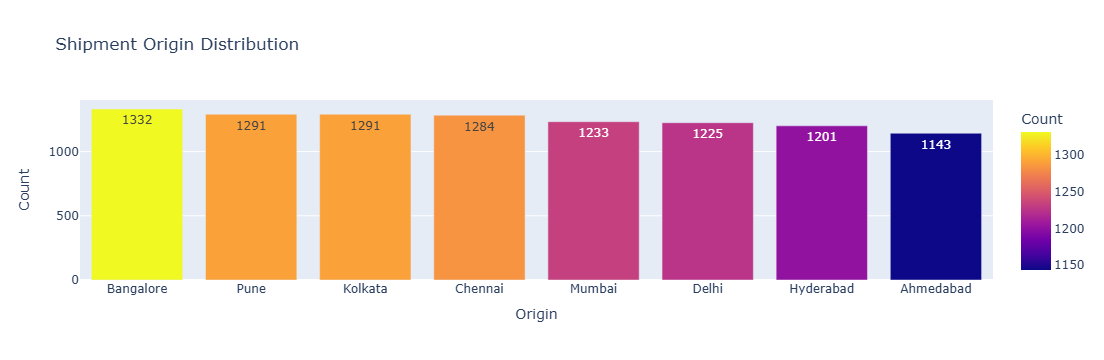

In [26]:
origin=df["origin"].value_counts().reset_index()
origin.columns=["Origin","Count"]
fig=px.bar(origin,x="Origin",y="Count",color="Count",text="Count",color_continuous_scale="Plasma",title="Shipment Origin Distribution")
fig.show()

## Shipment Destination

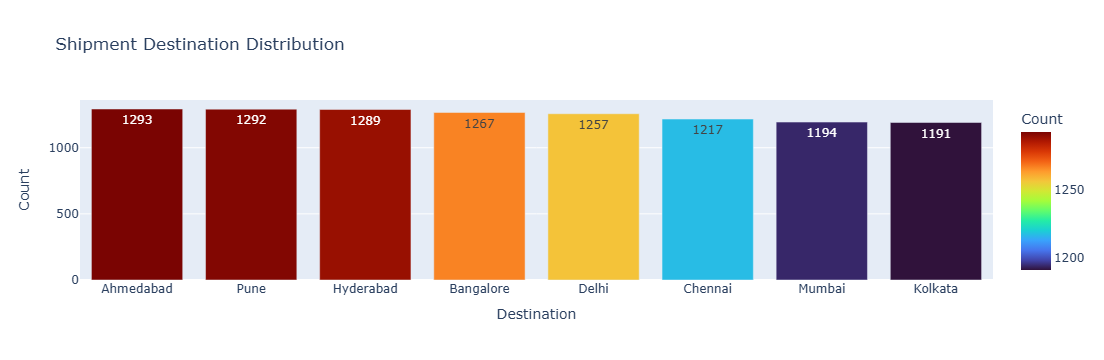

In [27]:
destination=df["destination"].value_counts().reset_index()
destination.columns=["Destination","Count"]
fig=px.bar(destination,x="Destination",y="Count",color="Count",text="Count",color_continuous_scale="Turbo",title="Shipment Destination Distribution")
fig.show()

## Correlation Heatmap

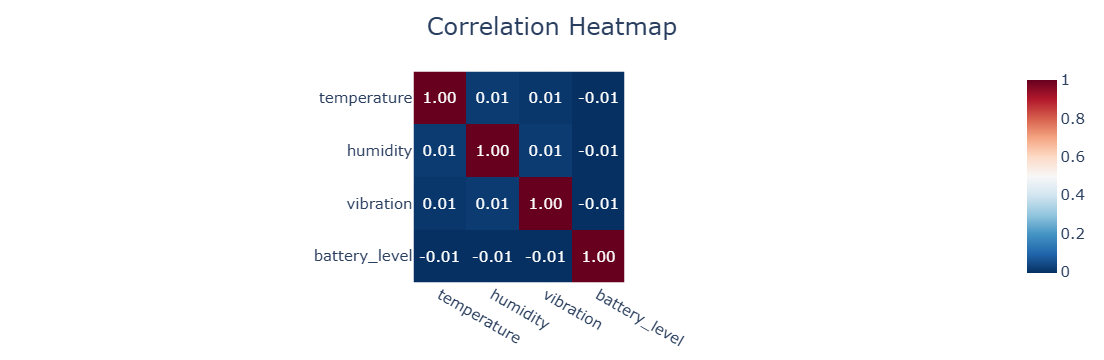

In [29]:
corr=df[["temperature","humidity","vibration","battery_level"]].corr()
fig=px.imshow(corr,text_auto=".2f",color_continuous_scale="RdBu_r",title="Correlation Heatmap")
fig.update_layout(**layout)
fig.show()

## Temperature by Fruit

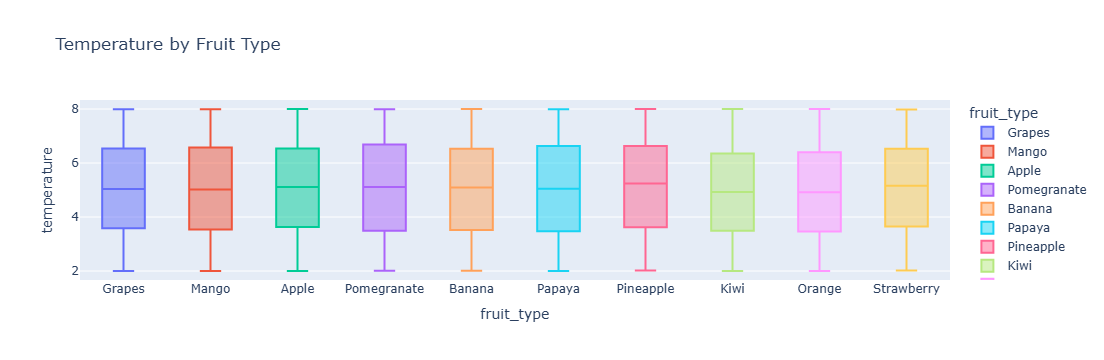

In [30]:
fig=px.box(df,x="fruit_type",y="temperature",color="fruit_type",title="Temperature by Fruit Type",points="outliers")
fig.show()